# Elastic plots

This tutorial was prepared by Alexandre Olender: olender@usp.br

This tutorial demonstrates Spiro's plotting utilities in the isotropic elastic wave problem. We will plot:
1. A high-resolution velocity model;
2. Wavefield solved at a given timestep;
3. An individual receiver trace;
4. A complete shot record."

In [1]:
# Code in this cell enables plotting in the notebook
%matplotlib inline

import spyro
import numpy as np

In [3]:
source_z = -1.1
receiver_z = -1.9
edge_length = 0.02
receiver_locations = spyro.create_transect((receiver_z, 1.2), (receiver_z, 1.8), 300)

dictionary = {
    "options": {
        "cell_type": "Q",
        "variant": "lumped",
        "degree": 4,
        "dimension": 2,
    },
    "parallelism": {
        "type": "automatic",
    },
    "mesh": {
        "length_z": 3.0,
        "length_x": 3.0,
        "mesh_file": None,
        "mesh_type": "firedrake_mesh",
    },
    "acquisition": {
        "source_type": "ricker",
        "source_locations": [(source_z, 1.5)],
        "frequency": 5.0,
        "delay": 0.2,
        "delay_type": "time",
        "receiver_locations": receiver_locations,
        "amplitude": np.array([0.0, 1.0]),
    },
    "time_axis": {
        "initial_time": 0.0,
        "final_time": 1.5,
        "dt": 0.001,
        "output_frequency": 100,
        "gradient_sampling_frequency": 1,
    },
    "visualization": {
        "forward_output": False,
        "fwi_velocity_model_output": False,
        "gradient_output": False,
        "adjoint_output": False,
        "debug_output": False,
    },
}

dictionary["synthetic_data"] = {
    "type": "object",
    "density": 0.1,
    "p_wave_velocity": 1.5,
    "s_wave_velocity": 1.0,
    "real_velocity_file": None,
}
dictionary["acquisition"]["amplitude"] = np.array([0.0, 1.0])
wave = spyro.IsotropicWave(dictionary)
wave.set_mesh(input_mesh_parameters={"edge_length": edge_length, "periodic": False})



Parallelism type: automatic
No Absorbing Boundary Conditions (ABCs) applied.
Pad length will be determined with HABC criterion
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Skipping mesh generation, since we don't have all the parameters
Creating firedrake_mesh type mesh.


/workspaces/fwi_examples/spyro/solvers/wave.py:166: UserWarning: No mesh file, Firedrake mesh will be automatically generated.
  warnings.warn(


Mesh Created with 22801 Nodes and 22500 Area Elements


In [4]:
wave.forward_solve()


Solving Forward Problem


/usr/local/lib/python3.12/dist-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type TensorProductQuadratureRule, don't know if this is safe.
  warnings.warn(


Simulation time is:        0.0 seconds


/usr/local/lib/python3.12/dist-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type TensorProductQuadratureRule, don't know if this is safe.
  warnings.warn(


Simulation time is:        0.1 seconds
Simulation time is:        0.2 seconds
Simulation time is:        0.3 seconds
Simulation time is:        0.4 seconds
Simulation time is:        0.5 seconds
Simulation time is:        0.6 seconds
Simulation time is:        0.7 seconds
Simulation time is:        0.8 seconds
Simulation time is:        0.9 seconds
Simulation time is:        1.0 seconds
Simulation time is:        1.1 seconds
Simulation time is:        1.2 seconds
Simulation time is:        1.3 seconds
Simulation time is:        1.4 seconds
Simulation time is:        1.5 seconds


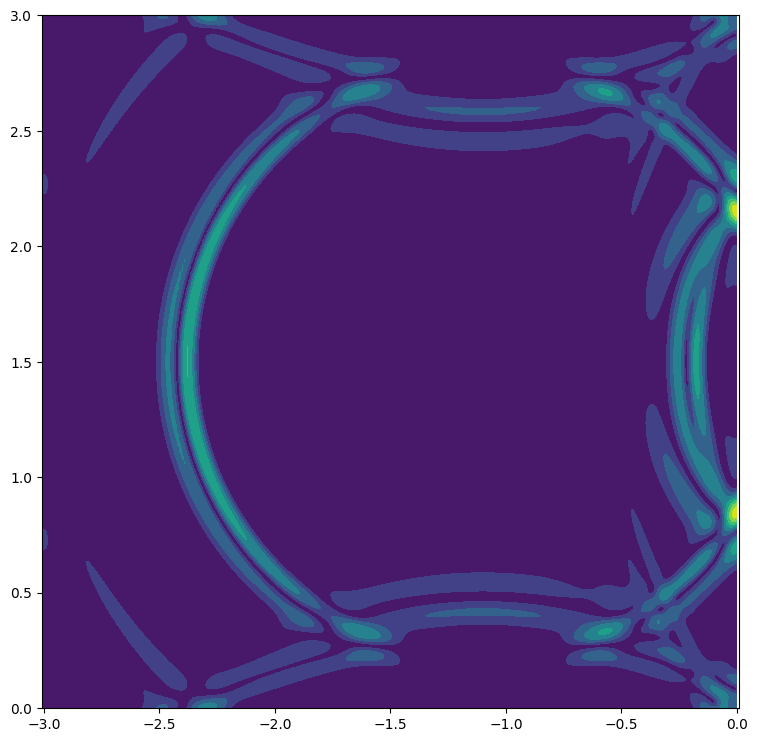

In [5]:
spyro.plots.plot_function(wave.u_n)

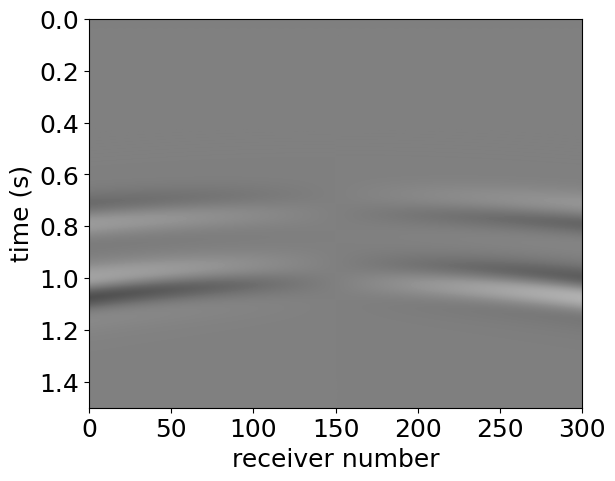

In [6]:
last_displacement = wave.u_n.dat.data[:]
u_max = np.max(np.abs(last_displacement[:, 0]))
spyro.plots.plot_shots(wave, contour_lines=100, vmin=-u_max, vmax=u_max, show=True, out_index=0)

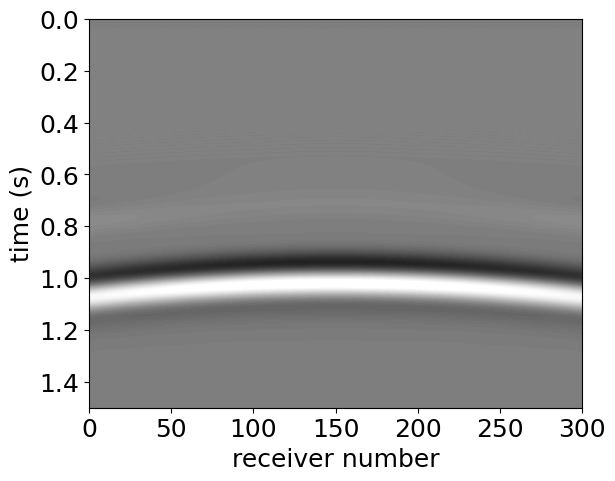

In [7]:

u_max = np.max(np.abs(last_displacement[:, 1]))
spyro.plots.plot_shots(wave, contour_lines=100, vmin=-u_max, vmax=u_max, show=True, out_index=1)